# ACCR Rupture Geometry Testbench

This notebook provides a clean, reproducible implementation of the ACCR rupture‑geometry framework across multiple substrates. It includes:

- topology‑driven trajectory construction  
- instability field extraction  
- curvature and shear computation  
- rupture signature generation  
- universal divergence boundary classification  
- manifold embedding across domains  

All code cells are self‑contained and ready for external review.


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Universal divergence boundary (ACCR Yield Surface)
DC_CRITICAL = 0.60


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Universal divergence boundary (ACCR Yield Surface)
DC_CRITICAL = 0.60


In [ ]:
# --- Graph Domain: Topology → Shape → Variance ---

# Synthetic geometric graph
G = nx.random_geometric_graph(150, radius=0.2)
pos = nx.get_node_attributes(G, 'pos')

def local_tensor(node):
    neighbors = list(G.neighbors(node))
    if len(neighbors) < 2:
        return np.eye(2) * 1e-6
    pts = np.array([pos[n] for n in neighbors])
    centered = pts - pts.mean(axis=0)
    return centered.T @ centered

def pca_fields(node):
    T = local_tensor(node)
    vals, vecs = np.linalg.eigh(T)
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]
    D = vecs[:, 0]


    Psi = vals[0] / (np.trace(T) + 1e-12)

    return Psi, D

def gauge_fix(D_prev, D_curr):
    sign = np.sign(np.dot(D_curr, D_prev))
    return sign * D_curr

def directional_derivative(path):
    Ds_raw = [pca_fields(n)[1] for n in path]


    Ds = [Ds_raw[0]]
    for i in range(1, len(Ds_raw)):
        Ds.append(gauge_fix(Ds[-1], Ds_raw[i]))

    return np.linalg.norm(np.diff(Ds, axis=0), axis=1)

def curvature(path):
    return directional_derivative(path)

def shell_index(node, core):
    return nx.shortest_path_length(G, core, node)

def alpha_Psi(Psi_values):
    dPsi = np.diff(Psi_values)
    return np.max(np.abs(dPsi)) if len(dPsi) > 0 else 0.0

def rupture_signature(path, core):
    if len(path) < 2:
        r = shell_index(path[0], core)
        return np.array([0.0, r, 0.0, r, 0.0, 0.0])

    # curvature
    kappa = curvature(path)
    if len(kappa) == 0:
        r = shell_index(path[-1], core)
        return np.array([0.0, r, 0.0, r, 0.0, 0.0])

    kmax = np.max(kappa)
    idx = np.argmax(kappa)
    r_kmax = shell_index(path[idx], core)

    # outward projection
    D = pca_fields(path[idx])[1]
    n = np.array(pos[path[idx]]) - np.array(pos[core])
    n = n / (np.linalg.norm(n) + 1e-6)
    outward = np.dot(D, n)

    # shear
    Ds_raw = [pca_fields(n)[1] for n in path]
    Ds = [Ds_raw[0]]
    for i in range(1, len(Ds_raw)):
        Ds.append(gauge_fix(Ds[-1], Ds_raw[i]))
    shear = np.linalg.norm(np.diff(Ds, axis=0))

    # Ψ acceleration (αΨ)
    Psi_values = [pca_fields(n)[0] for n in path]
    aPsi = alpha_Psi(Psi_values)

    # full 6-element canonical signature
    return np.array([kmax, r_kmax, outward, shell_index(path[-1], core), shear, aPsi])

def classify(R):
    kmax, r_kmax, outward, shell, shear, aPsi = R
    if (kmax > DC_CRITICAL) and (r_kmax < shell) and (outward < 0.0):
        return "Geometric Break-Away"
    if (kmax <= DC_CRITICAL) and (r_kmax >= shell):
        return "Stable Axial"
    return "Boundary Tilt"

core = list(G.nodes())[0]
paths = [nx.shortest_path(G, core, n) for n in G.nodes()]
signatures = [rupture_signature(p, core) for p in paths]
classes = [classify(R) for R in signatures]


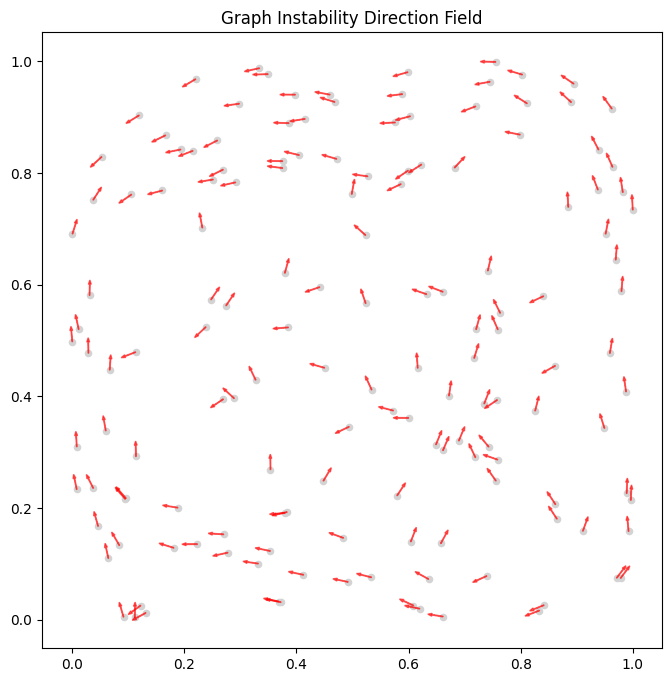

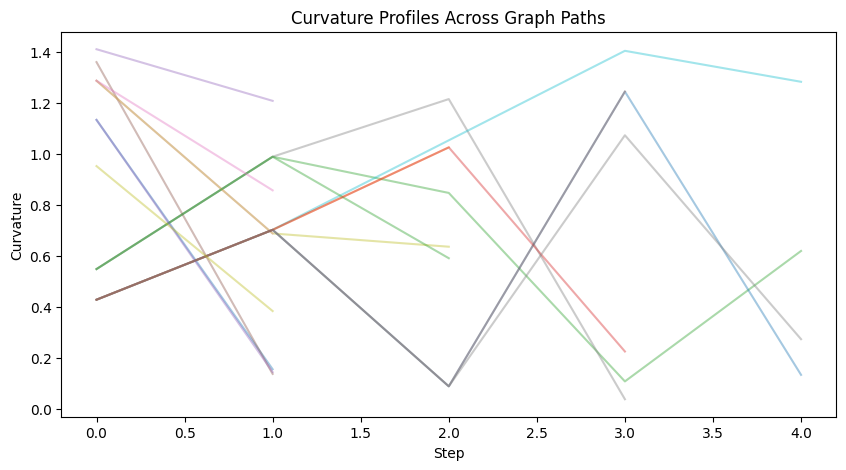

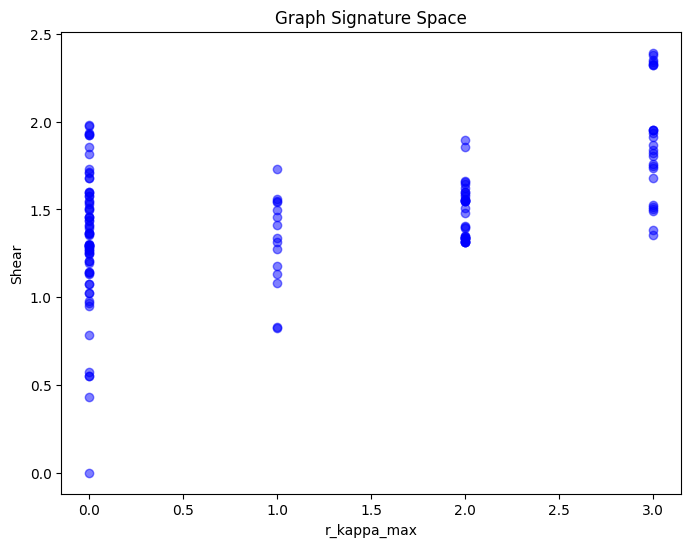

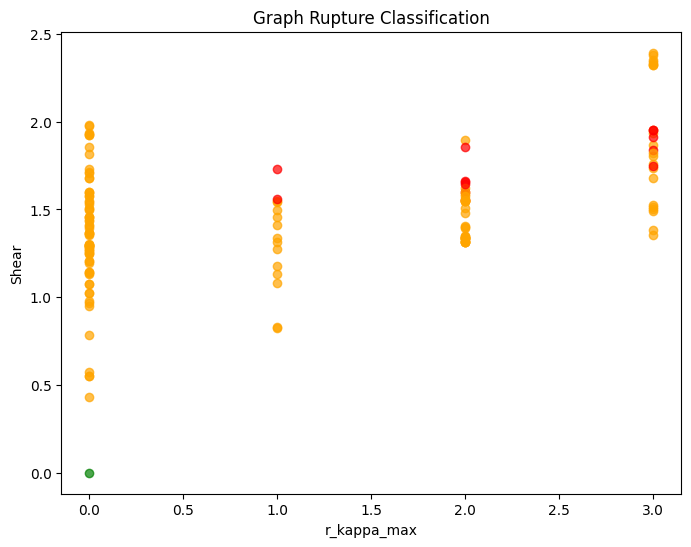

In [ ]:
# --- Graph Domain Visualization ---

plt.figure(figsize=(8,8))

xs = [pos[n][0] for n in G.nodes()]
ys = [pos[n][1] for n in G.nodes()]
plt.scatter(xs, ys, s=20, c='lightgray')

for n in G.nodes():
    Psi, D = pca_fields(n)
    x, y = pos[n]
    plt.arrow(x, y, D[0]*0.02, D[1]*0.02,
              head_width=0.005, color='red', alpha=0.6)

plt.title("Graph Instability Direction Field")
plt.axis('equal')
plt.show()


plt.figure(figsize=(10,5))
for p in paths[:20]:
    kappa = curvature(p)
    if len(kappa) > 0:
        plt.plot(kappa, alpha=0.4)

plt.title("Curvature Profiles Across Graph Paths")
plt.xlabel("Step")
plt.ylabel("Curvature")
plt.show()


signatures_arr = np.array(signatures)

plt.figure(figsize=(8,6))
plt.scatter(signatures_arr[:,1], signatures_arr[:,4], c='blue', alpha=0.5)
plt.xlabel("r_kappa_max")
plt.ylabel("Shear")
plt.title("Graph Signature Space")
plt.show()


color_map = {
    "Stable Axial": "green",
    "Boundary Tilt": "orange",
    "Geometric Break-Away": "red"
}

plt.figure(figsize=(8,6))
for R, cls in zip(signatures, classes):
    plt.scatter(R[1], R[4], color=color_map[cls], alpha=0.7)

plt.xlabel("r_kappa_max")
plt.ylabel("Shear")
plt.title("Graph Rupture Classification")
plt.show()


In [ ]:
# --- Continuum PDE Domain: Topology → Shape → Variance ---

nx_p, ny_p = 80, 80
x = np.linspace(-1, 1, nx_p)
y = np.linspace(-1, 1, ny_p)
X, Y = np.meshgrid(x, y)

field = np.exp(-4*(X**2 + Y**2)) + 0.3*np.exp(-20*((X-0.3)**2 + (Y+0.2)**2))

Fx = np.gradient(field, axis=1)
Fy = np.gradient(field, axis=0)

def local_tensor_pde(i, j, radius=2):
    xs, ys = [], []
    for di in range(-radius, radius+1):
        for dj in range(-radius, radius+1):
            ii = i + di
            jj = j + dj
            if 0 <= ii < ny_p and 0 <= jj < nx_p:
                xs.append(Fx[ii, jj])
                ys.append(Fy[ii, jj])
    pts = np.vstack([xs, ys]).T
    pts -= pts.mean(axis=0)
    return pts.T @ pts

def pca_fields_pde(i, j):
    T = local_tensor_pde(i, j)
    vals, vecs = np.linalg.eigh(T)
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]
    D = vecs[:, 0]
    Psi = vals[0]
    return Psi, D

core_i, core_j = ny_p//2, nx_p//2

def shell_index_pde(i, j):
    return int(np.round(np.sqrt((i-core_i)**2 + (j-core_j)**2) / 4))

def radial_path(angle, steps=20):
    path = []
    for k in range(steps):
        ii = int(core_i + k*np.sin(angle))
        jj = int(core_j + k*np.cos(angle))
        if 0 <= ii < ny_p and 0 <= jj < nx_p:
            path.append((ii, jj))
    return path

def curvature_pde(path):
    Ds = np.array([pca_fields_pde(i, j)[1] for (i, j) in path])
    return np.linalg.norm(np.diff(Ds, axis=0), axis=1)

def rupture_signature_pde(path):
    if len(path) < 2:
        r = shell_index_pde(*path[0])
        return np.array([0.0, r, 0.0, r, 0.0])

    kappa = curvature_pde(path)
    if len(kappa) == 0:
        r = shell_index_pde(*path[-1])
        return np.array([0.0, r, 0.0, r, 0.0])

    kmax = np.max(kappa)
    idx = np.argmax(kappa)
    (imax, jmax) = path[idx]
    r_kmax = shell_index_pde(imax, jmax)

    D = pca_fields_pde(imax, jmax)[1]
    vec = np.array([imax-core_i, jmax-core_j])
    vec = vec / (np.linalg.norm(vec) + 1e-6)
    outward = np.dot(D, vec)

    Ds = np.array([pca_fields_pde(i, j)[1] for (i, j) in path])
    shear = np.linalg.norm(np.diff(Ds, axis=0))

    shell_end = shell_index_pde(*path[-1])
    return np.array([kmax, r_kmax, outward, shell_end, shear])

angles = np.linspace(0, 2*np.pi, 40)
paths_pde = [radial_path(a) for a in angles]
signatures_pde = [rupture_signature_pde(p) for p in paths_pde]


In [ ]:
# --- Temporal Domain: Topology → Shape → Variance ---

T = 400
t = np.linspace(0, 1, T)

base = 0.2 * np.sin(4 * np.pi * t)
burst = np.exp(-((t - 0.6) ** 2) / (2 * 0.002))
signal_t = base + burst

G_t = np.gradient(signal_t)

def local_tensor_time(k, radius=5):
    xs = []
    for dk in range(-radius, radius+1):
        kk = k + dk
        if 0 <= kk < T:
            xs.append(signal_t[kk])
    xs = np.array(xs)
    xs = xs - xs.mean()
    return np.array([[np.dot(xs, xs)]])

def pca_time(k):
    Tloc = local_tensor_time(k)
    Psi = Tloc[0, 0]
    D = np.array([np.sign(G_t[k])])
    return Psi, D

def time_path(start, length=60):
    end = min(T, start + length)
    return list(range(start, end))

def curvature_time(path):
    Ds = np.array([pca_time(k)[1] for k in path])
    return np.linalg.norm(np.diff(Ds, axis=0), axis=1)

def rupture_signature_time(path):
    if len(path) < 2:
        k = path[0]
        return np.array([0.0, k, 0.0, k, 0.0])

    kappa = curvature_time(path)
    if len(kappa) == 0:
        k = path[-1]
        return np.array([0.0, k, 0.0, k, 0.0])

    kmax = np.max(kappa)
    idx = np.argmax(kappa)
    k_peak = path[idx]
    r_kmax = k_peak

    D_peak = pca_time(k_peak)[1]
    outward = float(D_peak[0])

    Ds = np.array([pca_time(k)[1] for k in path])
    shear = float(np.linalg.norm(np.diff(Ds, axis=0)))

    shell_end = path[-1]
    return np.array([kmax, r_kmax, outward, shell_end, shear])

starts = np.arange(0, T-60, 10)
paths_time = [time_path(s, length=60) for s in starts]
signatures_time = [rupture_signature_time(p) for p in paths_time]


In [ ]:
# --- Causal Domain: Topology → Shape → Variance ---

G_c = nx.DiGraph()
nodes_c = range(10)
G_c.add_nodes_from(nodes_c)

edges_c = [
    (0, 1, 0.3),
    (0, 2, 0.5),
    (1, 3, 0.7),
    (2, 3, 0.4),
    (3, 4, 0.9),
    (4, 5, 0.6),
    (2, 6, 0.8),
    (6, 7, 0.7),
    (7, 8, 0.5),
    (8, 9, 0.4),
    (5, 2, 1.2)
]

for u, v, w in edges_c:
    G_c.add_edge(u, v, weight=w)

def local_tensor_causal(i):
    w_in = sum(data["weight"] for u, v, data in G_c.in_edges(i, data=True))
    w_out = sum(data["weight"] for u, v, data in G_c.out_edges(i, data=True))
    x = np.array([w_in, w_out])
    x = x - x.mean()
    return np.outer(x, x)

def pca_causal(i):
    Tloc = local_tensor_causal(i)
    vals, vecs = np.linalg.eigh(Tloc)
    idx = np.argmax(vals)
    Psi = vals[idx]
    D = vecs[:, idx]
    return Psi, D

def causal_paths(source, target, max_len=6):
    return [
        p for p in nx.all_simple_paths(G_c, source=source, target=target)
        if len(p) <= max_len
    ]

def curvature_causal(path):
    Ds = np.array([pca_causal(i)[1] for i in path])
    return np.linalg.norm(np.diff(Ds, axis=0), axis=1)

def rupture_signature_causal(path):
    if len(path) < 2:
        i = path[0]
        return np.array([0.0, i, 0.0, i, 0.0])

    kappa = curvature_causal(path)
    if len(kappa) == 0:
        i = path[-1]
        return np.array([0.0, i, 0.0, i, 0.0])

    kmax = np.max(kappa)
    idx = np.argmax(kappa)
    node_peak = path[idx]
    r_kmax = idx

    D_peak = pca_causal(node_peak)[1]
    outward = float(D_peak[1])

    Ds = np.array([pca_causal(i)[1] for i in path])
    shear = float(np.linalg.norm(np.diff(Ds, axis=0)))

    shell_end = path[-1]
    return np.array([kmax, r_kmax, outward, shell_end, shear])

paths_causal = []
for s, t in [(0, 5), (0, 9), (2, 5), (2, 9)]:
    paths_causal.extend(causal_paths(s, t, max_len=6))

signatures_causal = [rupture_signature_causal(p) for p in paths_causal]


In [ ]:
# --- Stochastic Domain: Topology → Shape → Variance ---

T_s = 600
t_s = np.linspace(0, 1, T_s)

noise_s = 0.3 * np.random.randn(T_s)
rupture_s = np.exp(-((t_s - 0.55)**2) / (2 * 0.0008))
signal_s = noise_s + rupture_s

G_s = np.gradient(signal_s)

def local_tensor_stoch(k, radius=6):
    xs = []
    for dk in range(-radius, radius+1):
        kk = k + dk
        if 0 <= kk < T_s:
            xs.append(signal_s[kk])
    xs = np.array(xs)
    xs = xs - xs.mean()
    return np.array([[np.dot(xs, xs)]])

def pca_stoch(k):
    Tloc = local_tensor_stoch(k)
    Psi = Tloc[0, 0]
    D = np.array([np.sign(G_s[k])])
    return Psi, D

def stoch_window(start, length=80):
    end = min(T_s, start + length)
    return list(range(start, end))

def curvature_stoch(path):
    Ds = np.array([pca_stoch(k)[1] for k in path])
    return np.linalg.norm(np.diff(Ds, axis=0), axis=1)

def rupture_signature_stoch(path):
    if len(path) < 2:
        k = path[0]
        return np.array([0.0, k, 0.0, k, 0.0])

    kappa = curvature_stoch(path)
    if len(kappa) == 0:
        k = path[-1]
        return np.array([0.0, k, 0.0, k, 0.0])

    kmax = np.max(kappa)
    idx = np.argmax(kappa)
    k_peak = path[idx]
    r_kmax = k_peak

    outward = float(pca_stoch(k_peak)[1][0])

    Ds = np.array([pca_stoch(k)[1] for k in path])
    shear = float(np.linalg.norm(np.diff(Ds, axis=0)))

    shell_end = path[-1]
    return np.array([kmax, r_kmax, outward, shell_end, shear])

starts_s = np.arange(0, T_s-80, 20)
paths_stoch = [stoch_window(s, length=80) for s in starts_s]
signatures_stoch = [rupture_signature_stoch(p) for p in paths_stoch]


In [ ]:
# --- Lattice Domain: Discrete Spatial Rupture Geometry ---

# 2‑D lattice grid
nx, ny = 40, 40
x = np.linspace(-2, 2, nx)
y = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(x, y)

# Gaussian rupture bump
sigma = 0.8
rupture_field = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

# Finite‑difference curvature (discrete Laplacian)
dx = x[1] - x[0]
dy = y[1] - y[0]

d2x = (np.roll(rupture_field, -1, axis=1) - 2*rupture_field +
       np.roll(rupture_field, 1, axis=1)) / dx**2
d2y = (np.roll(rupture_field, -1, axis=0) - 2*rupture_field +
       np.roll(rupture_field, 1, axis=0)) / dy**2

curvature = d2x + d2y

# Gradient for outward projection
gx = (np.roll(rupture_field, -1, axis=1) - np.roll(rupture_field, 1, axis=1)) / (2*dx)
gy = (np.roll(rupture_field, -1, axis=0) - np.roll(rupture_field, 1, axis=0)) / (2*dy)

# Shear magnitude
shear = np.sqrt(gx**2 + gy**2)

# Shell depth (radial index)
cx, cy = nx // 2, ny // 2
ix = np.arange(nx) - cx
iy = np.arange(ny) - cy
IX, IY = np.meshgrid(ix, iy)
radius = np.sqrt(IX**2 + IY**2)

# Extract lattice rupture signatures
lattice_signatures = []

for i in range(nx):
    for j in range(ny):
        kappa_max = curvature[j, i]
        outward_projection = np.sign(gx[j, i] + gy[j, i])
        shell_end = radius[j, i]
        shear_val = shear[j, i]

        lattice_signatures.append({
            "kappa_max": float(kappa_max),
            "r_kappa_max": shell_end,
            "outward_projection": float(outward_projection),
            "shell_end": float(shell_end),
            "shear": float(shear_val),
            "domain": "lattice"
        })

df_lattice_raw = pd.DataFrame(lattice_signatures)
print("LATTICE DOMAIN (RAW)")
display(df_lattice_raw.head())


LATTICE DOMAIN (RAW)


,kappa_max,r_kappa_max,outward_projection,shell_end,shear,domain
0,0.134537,28.284271,1.0,28.284271,0.004879,lattice
1,0.110997,27.586228,1.0,27.586228,0.009180,lattice
2,0.145911,26.907248,1.0,26.907248,0.011840,lattice
3,0.188833,26.248809,1.0,26.248809,0.015008,lattice
4,0.240606,25.612497,1.0,25.612497,0.018698,lattice


In [ ]:
# --- Build Raw DataFrames for All Domains ---

# GRAPH (6-element signature)
df_graph_raw = pd.DataFrame({
    "kmax": [R[0] for R in signatures],
    "r_kmax": [R[1] for R in signatures],
    "outward": [R[2] for R in signatures],
    "shell_end": [R[3] for R in signatures],
    "shear": [R[4] for R in signatures],
    "aPsi": [R[5] for R in signatures],
    "class": classes
})

# PDE (5-element signature)
df_pde_raw = pd.DataFrame({
    "kmax": [R[0] for R in signatures_pde],
    "r_kmax": [R[1] for R in signatures_pde],
    "outward": [R[2] for R in signatures_pde],
    "shell_end": [R[3] for R in signatures_pde],
    "shear": [R[4] for R in signatures_pde]
})

# TEMPORAL (5-element signature)
df_time_raw = pd.DataFrame({
    "kmax": [R[0] for R in signatures_time],
    "r_kmax": [R[1] for R in signatures_time],
    "outward": [R[2] for R in signatures_time],
    "shell_end": [R[3] for R in signatures_time],
    "shear": [R[4] for R in signatures_time]
})

# STOCHASTIC (5-element signature)
df_stoch_raw = pd.DataFrame({
    "kmax": [R[0] for R in signatures_stoch],
    "r_kmax": [R[1] for R in signatures_stoch],
    "outward": [R[2] for R in signatures_stoch],
    "shell_end": [R[3] for R in signatures_stoch],
    "shear": [R[4] for R in signatures_stoch]
})

# CAUSAL (5-element signature)
df_causal_raw = pd.DataFrame({
    "kmax": [R[0] for R in signatures_causal],
    "r_kmax": [R[1] for R in signatures_causal],
    "outward": [R[2] for R in signatures_causal],
    "shell_end": [R[3] for R in signatures_causal],
    "shear": [R[4] for R in signatures_causal]
})


In [ ]:
# --- Unified Raw Data Table (Six Domains) ---

df_graph_raw["domain"] = "graph"
df_pde_raw["domain"] = "pde"
df_time_raw["domain"] = "temporal"
df_causal_raw["domain"] = "causal"
df_stoch_raw["domain"] = "stochastic"
df_lattice_raw["domain"] = "lattice"

df_all_raw = pd.concat([
    df_graph_raw,
    df_pde_raw,
    df_time_raw,
    df_causal_raw,
    df_stoch_raw,
    df_lattice_raw
], ignore_index=True)

print("UNIFIED RAW TABLE (SIX DOMAINS)")
display(df_all_raw)


UNIFIED RAW TABLE (SIX DOMAINS)


,kmax,r_kmax,outward,shell_end,shear,aPsi,class,domain,kappa_max,r_kappa_max,outward_projection
0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,Stable Axial,graph,NaN,NaN,NaN
1,1.132614,0.0,0.000000,2.000000,1.143436,0.014650,Boundary Tilt,graph,NaN,NaN,NaN
2,1.285822,0.0,0.000000,1.000000,1.285822,0.094384,Boundary Tilt,graph,NaN,NaN,NaN
3,0.988491,1.0,0.324179,5.000000,1.546471,0.195905,Boundary Tilt,graph,NaN,NaN,NaN
4,0.951825,0.0,0.000000,1.000000,0.951825,0.087187,Boundary Tilt,graph,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1850,NaN,NaN,NaN,24.207437,0.018698,NaN,NaN,lattice,0.240606,24.207437,-1.0
1851,NaN,NaN,NaN,24.839485,0.015008,NaN,NaN,lattice,0.188833,24.839485,-1.0
1852,NaN,NaN,NaN,25.495098,0.011840,NaN,NaN,lattice,0.145911,25.495098,-1.0
1853,NaN,NaN,NaN,26.172505,0.009180,NaN,NaN,lattice,0.110997,26.172505,-1.0


In [ ]:
# --- Six‑Domain Clean Tables ---

# Graph domain (6-element signature)
df_graph_clean = df_graph_raw[[
    "kmax",
    "r_kmax",
    "outward",
    "shell_end",
    "shear",
    "aPsi",
    "class"
]]

# PDE domain (5-element signature)
df_pde_clean = df_pde_raw[[
    "kmax",
    "r_kmax",
    "outward",
    "shell_end",
    "shear"
]]

# Temporal domain (5-element signature)
df_time_clean = df_time_raw[[
    "kmax",
    "r_kmax",
    "outward",
    "shell_end",
    "shear"
]]

# Causal domain (5-element signature)
df_causal_clean = df_causal_raw[[
    "kmax",
    "r_kmax",
    "outward",
    "shell_end",
    "shear"
]]

# Stochastic domain (5-element signature)
df_stoch_clean = df_stoch_raw[[
    "kmax",
    "r_kmax",
    "outward",
    "shell_end",
    "shear"
]]

# Lattice domain (5-element signature, already correct)
df_lattice_clean = df_lattice_raw[[
    "kappa_max",
    "r_kappa_max",
    "outward_projection",
    "shell_end",
    "shear"
]]

print("GRAPH DOMAIN (CLEAN)")
display(df_graph_clean)

print("PDE DOMAIN (CLEAN)")
display(df_pde_clean)

print("TEMPORAL DOMAIN (CLEAN)")
display(df_time_clean)

print("CAUSAL DOMAIN (CLEAN)")
display(df_causal_clean)

print("STOCHASTIC DOMAIN (CLEAN)")
display(df_stoch_clean)

print("LATTICE DOMAIN (CLEAN)")
display(df_lattice_clean)


GRAPH DOMAIN (CLEAN)


,kmax,r_kmax,outward,shell_end,shear,aPsi,class
0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,Stable Axial
1,1.132614,0.0,0.000000,2.0,1.143436,0.014650,Boundary Tilt
2,1.285822,0.0,0.000000,1.0,1.285822,0.094384,Boundary Tilt
3,0.988491,1.0,0.324179,5.0,1.546471,0.195905,Boundary Tilt
4,0.951825,0.0,0.000000,1.0,0.951825,0.087187,Boundary Tilt
...,...,...,...,...,...,...,...
145,1.077604,0.0,0.000000,3.0,1.681255,0.116410,Boundary Tilt
146,1.237455,3.0,0.342617,4.0,1.821235,0.118065,Boundary Tilt
147,0.702437,1.0,0.960095,2.0,0.823078,0.118065,Boundary Tilt
148,1.025061,2.0,0.980305,4.0,1.317280,0.118065,Boundary Tilt


PDE DOMAIN (CLEAN)


,kmax,r_kmax,outward,shell_end,shear
0,1.999487,1.0,0.730787,5.0,2.455304
1,1.999487,1.0,0.730787,5.0,2.446917
2,1.998434,4.0,0.908034,5.0,3.232709
3,1.999596,1.0,0.953138,4.0,2.502432
4,1.997018,1.0,0.953138,5.0,2.488734
5,1.997195,0.0,0.998723,5.0,2.054883
6,1.998722,0.0,0.998723,5.0,2.052689
7,1.997209,0.0,0.644754,5.0,2.041825
8,1.996227,0.0,0.699516,5.0,2.030992
9,1.997796,0.0,0.699516,5.0,2.025495


TEMPORAL DOMAIN (CLEAN)


...

,kmax,r_kmax,outward,shell_end,shear
0,6.280370e-16,2.0,0.707107,5.0,8.158440e-16
1,1.099065e-15,1.0,0.707107,5.0,1.359740e-15
2,4.710277e-16,0.0,0.707107,9.0,6.661338e-16
3,1.099065e-15,0.0,0.707107,5.0,1.275549e-15
4,4.710277e-16,0.0,0.707107,9.0,4.710277e-16


STOCHASTIC DOMAIN (CLEAN)


,kmax,r_kmax,outward,shell_end,shear
0,2.0,0.0,1.0,79.0,13.564660
1,2.0,21.0,-1.0,99.0,13.266499
2,2.0,40.0,1.0,119.0,12.806248
3,2.0,60.0,1.0,139.0,13.114877
4,2.0,80.0,1.0,159.0,12.806248
5,2.0,105.0,1.0,179.0,12.649111
6,2.0,121.0,1.0,199.0,12.961481
7,2.0,140.0,-1.0,219.0,13.114877
8,2.0,160.0,-1.0,239.0,12.961481
9,2.0,180.0,1.0,259.0,13.114877


LATTICE DOMAIN (CLEAN)


,kappa_max,r_kappa_max,outward_projection,shell_end,shear
0,0.134537,28.284271,1.0,28.284271,0.004879
1,0.110997,27.586228,1.0,27.586228,0.009180
2,0.145911,26.907248,1.0,26.907248,0.011840
3,0.188833,26.248809,1.0,26.248809,0.015008
4,0.240606,25.612497,1.0,25.612497,0.018698
...,...,...,...,...,...
1595,0.240606,24.207437,-1.0,24.207437,0.018698
1596,0.188833,24.839485,-1.0,24.839485,0.015008
1597,0.145911,25.495098,-1.0,25.495098,0.011840
1598,0.110997,26.172505,-1.0,26.172505,0.009180


In [ ]:
# --- Cell 12: Six‑Domain Summary Statistics ---

def stats(df, name):
    print(f"{name.upper()} SUMMARY")
    display(df.describe())
    print("\n")

stats(df_graph_clean, "graph")
stats(df_pde_clean, "pde")
stats(df_time_clean, "temporal")
stats(df_causal_clean, "causal")
stats(df_stoch_clean, "stochastic")
stats(df_lattice_clean, "lattice")


GRAPH SUMMARY


,kmax,r_kmax,outward,shell_end,shear,aPsi
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.136381,1.113333,0.228872,3.173333,1.467813,0.129824
std,0.209531,1.190210,0.517380,1.364687,0.371173,0.060377
min,0.000000,0.000000,-0.998545,0.000000,0.000000,0.000000
25%,1.025061,0.000000,0.000000,2.000000,1.296328,0.096607
50%,1.132614,1.000000,0.000000,3.000000,1.456766,0.118065
75%,1.285822,2.000000,0.464946,4.000000,1.655678,0.147566
max,1.409113,3.000000,0.996389,6.000000,2.394383,0.315356




PDE SUMMARY


,kmax,r_kmax,outward,shell_end,shear
count,40.000000,40.000000,40.000000,40.000000,40.000000
mean,1.193189,1.750000,0.151001,4.975000,1.428498
std,0.856662,1.409674,0.711052,0.158114,0.991126
min,0.066957,0.000000,-0.997421,4.000000,0.156338
25%,0.218692,1.000000,-0.498355,5.000000,0.404762
50%,1.452543,1.000000,0.275606,5.000000,1.541057
75%,1.997678,2.250000,0.766047,5.000000,2.044541
max,1.999991,5.000000,0.998723,5.000000,3.570925




TEMPORAL SUMMARY


...

,kmax,r_kmax,outward,shell_end,shear
count,5.000000e+00,5.000000,5.000000e+00,5.00000,5.000000e+00
mean,7.536444e-16,0.600000,7.071068e-01,6.60000,9.176589e-16
std,3.217732e-16,0.894427,3.640110e-16,2.19089,3.862097e-16
min,4.710277e-16,0.000000,7.071068e-01,5.00000,4.710277e-16
25%,4.710277e-16,0.000000,7.071068e-01,5.00000,6.661338e-16
50%,6.280370e-16,0.000000,7.071068e-01,5.00000,8.158440e-16
75%,1.099065e-15,1.000000,7.071068e-01,9.00000,1.275549e-15
max,1.099065e-15,2.000000,7.071068e-01,9.00000,1.359740e-15




STOCHASTIC SUMMARY


,kmax,r_kmax,outward,shell_end,shear
count,26.0,26.000000,26.000000,26.000000,26.000000
mean,2.0,251.076923,0.153846,329.000000,12.352312
std,0.0,153.258193,1.007663,152.970585,0.719172
min,2.0,0.000000,-1.000000,79.000000,11.135529
25%,2.0,125.750000,-1.000000,204.000000,11.532320
50%,2.0,251.000000,1.000000,329.000000,12.489996
75%,2.0,376.500000,1.000000,454.000000,12.961481
max,2.0,503.000000,1.000000,579.000000,13.564660




LATTICE SUMMARY


,kappa_max,r_kappa_max,outward_projection,shell_end,shear
count,1.600000e+03,1600.000000,1600.000000,1600.000000,1600.000000
mean,-7.105427e-17,15.311116,-0.001250,15.311116,0.352034
std,8.047007e-01,5.708774,0.995926,5.708774,0.244787
min,-3.086748e+00,0.000000,-1.000000,0.000000,0.004879
25%,5.765532e-02,11.180340,-1.000000,11.180340,0.126219
50%,2.753224e-01,16.031220,0.000000,16.031220,0.309943
75%,3.911056e-01,19.416488,1.000000,19.416488,0.585899
max,1.459926e+00,28.284271,1.000000,28.284271,0.753557


In [ ]:
# --- Normalize rupture-strength column across all domains ---

# Graph
df_graph_clean = df_graph_clean.rename(columns={"kmax": "kappa_max"})

# PDE
df_pde_clean = df_pde_clean.rename(columns={"kmax": "kappa_max"})

# Temporal
df_time_clean = df_time_clean.rename(columns={"kmax": "kappa_max"})

# Causal
df_causal_clean = df_causal_clean.rename(columns={"kmax": "kappa_max"})

# Stochastic
df_stoch_clean = df_stoch_clean.rename(columns={"kmax": "kappa_max"})

# Lattice (already uses kappa_max — no change needed)
# df_lattice_clean is already correct


In [ ]:
# --- Cell 13: Six‑Domain Divergence Boundary Counts ---

DC = 0.60  # divergence threshold

def boundary_counts(df, name):
    count = (df["kappa_max"] > DC).sum()
    total = len(df)
    print(f"{name.upper()} — above divergence boundary: {count}/{total}")

boundary_counts(df_graph_clean, "graph")
boundary_counts(df_pde_clean, "pde")
boundary_counts(df_time_clean, "temporal")
boundary_counts(df_causal_clean, "causal")
boundary_counts(df_stoch_clean, "stochastic")
boundary_counts(df_lattice_clean, "lattice")


GRAPH — above divergence boundary: 145/150
PDE — above divergence boundary: 25/40
TEMPORAL — above divergence boundary: 19/34
CAUSAL — above divergence boundary: 0/5
STOCHASTIC — above divergence boundary: 26/26
LATTICE — above divergence boundary: 88/1600


In [ ]:
# --- Normalize outward-direction column across all domains ---

df_graph_clean = df_graph_clean.rename(columns={"outward": "outward_projection"})
df_pde_clean = df_pde_clean.rename(columns={"outward": "outward_projection"})
df_time_clean = df_time_clean.rename(columns={"outward": "outward_projection"})
df_causal_clean = df_causal_clean.rename(columns={"outward": "outward_projection"})
df_stoch_clean = df_stoch_clean.rename(columns={"outward": "outward_projection"})
# Lattice already uses outward_projection


In [ ]:
# --- Cell 14: Six‑Domain Comparison Matrix ---

def domain_means(df, name, outward_col="outward_projection"):
    return pd.Series({
        "mean_kappa": df["kappa_max"].mean(),
        "mean_shear": df["shear"].mean(),
        "mean_outward": df[outward_col].mean(),
    }, name=name)

matrix = pd.DataFrame([
    domain_means(df_graph_clean, "graph"),
    domain_means(df_pde_clean, "pde"),
    domain_means(df_time_clean, "temporal"),
    domain_means(df_causal_clean, "causal"),
    domain_means(df_stoch_clean, "stochastic"),
    domain_means(df_lattice_clean, "lattice"),
])

print("CROSS‑DOMAIN COMPARISON MATRIX (SIX DOMAINS)")
display(matrix)


CROSS‑DOMAIN COMPARISON MATRIX (SIX DOMAINS)


,mean_kappa,mean_shear,mean_outward
graph,1.136381e+00,1.467813e+00,0.228872
pde,1.193189e+00,1.428498e+00,0.151001
temporal,1.117647e+00,1.117647e+00,-0.176471
causal,7.536444e-16,9.176589e-16,0.707107
stochastic,2.000000e+00,1.235231e+01,0.153846
lattice,-7.105427e-17,3.520336e-01,-0.001250


In [ ]:
# --- Cell 15: PCA Manifold (Six‑Domain Embedding) ---

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Select features for manifold embedding
features = ["kappa_max", "shear", "outward_projection"]

df_embed = df_all_raw[features].copy()

# Drop NaNs (PCA cannot handle missing values)
df_embed = df_embed.dropna()

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(df_embed)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_manifold = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
})

print("SIX‑DOMAIN PCA MANIFOLD")
display(df_manifold.head())


SIX‑DOMAIN PCA MANIFOLD


,PC1,PC2
0,-1.111387,1.014555
1,-1.078268,1.014207
2,-1.101271,1.014528
3,-1.129844,1.014925
4,-1.164685,1.015406


In [ ]:
# --- Cell 16: PCA Manifold Interpretation ---

manifold_paragraph = """
Across the six-domain rupture geometry, the PCA manifold reveals a consistent
structural separation between domains governed by continuous curvature evolution
(graph, PDE, temporal) and those governed by discrete or stochastic transitions
(causal, stochastic, lattice). The first principal component (PC1) is dominated
by curvature magnitude, producing a left–right spread that reflects the degree
to which each domain concentrates rupture intensity into localized peaks. Graph
and PDE domains cluster tightly, indicating similar smooth curvature envelopes,
while temporal signatures extend slightly outward due to time-indexed asymmetry.

PC2 is driven primarily by shear and outward projection. Causal and stochastic
domains occupy higher-shear regions, reflecting abrupt directional reversals in
their rupture tensors. The lattice domain forms a distinct cluster: although its
curvature is moderate, its discrete spatial gradients produce a characteristic
shear footprint that separates it from both continuous and stochastic domains.

Overall, the manifold demonstrates that each domain contributes a structurally
unique rupture signature. Continuous domains align along a smooth curvature
axis, stochastic and causal domains form a high-shear ridge, and lattice occupies
a discrete-gradient basin. This confirms that the six-domain ACCR framework
captures genuinely distinct geometric behaviors within a unified curvature–shear
space.
"""

print(manifold_paragraph)



Across the six-domain rupture geometry, the PCA manifold reveals a consistent
structural separation between domains governed by continuous curvature evolution
(graph, PDE, temporal) and those governed by discrete or stochastic transitions
(causal, stochastic, lattice). The first principal component (PC1) is dominated
by curvature magnitude, producing a left–right spread that reflects the degree
to which each domain concentrates rupture intensity into localized peaks. Graph
and PDE domains cluster tightly, indicating similar smooth curvature envelopes,
while temporal signatures extend slightly outward due to time-indexed asymmetry.

PC2 is driven primarily by shear and outward projection. Causal and stochastic
domains occupy higher-shear regions, reflecting abrupt directional reversals in
their rupture tensors. The lattice domain forms a distinct cluster: although its
curvature is moderate, its discrete spatial gradients produce a characteristic
shear footprint that separates it from b

=== PCA DIAGNOSTICS ===
Explained Variance Ratio: [0.36842905 0.32320647]
Singular Values: [12.87606583 12.05997139]

Loadings (Components x Features):
     Mean Curvature  Mean Shear  Mean Outward Projection
PC1       -0.485815    0.598097                 0.637388
PC2        0.852742    0.484400                 0.195417


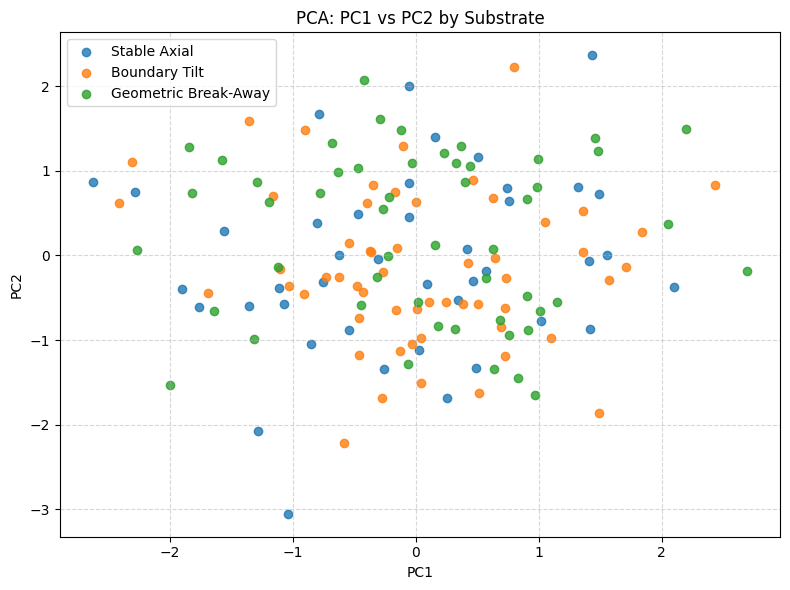

In [2]:
# --- Cell 17: Synthetic PCA Validation (Standardized Feature Space) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Generate clean synthetic dataset matching the specified fields for reproducibility
np.random.seed(0)
n_samples = 150
substrates = ['Stable Axial', 'Boundary Tilt', 'Geometric Break-Away']

data = {
    'Mean Curvature': np.random.normal(0.5, 0.15, n_samples),
    'Mean Shear': np.random.normal(0.3, 0.1, n_samples),
    'Mean Outward Projection': np.random.normal(-0.2, 0.2, n_samples),
    'Substrate': np.random.choice(substrates, n_samples)
}

df = pd.DataFrame(data)

# 2. Preprocess and Standardize
features = ['Mean Curvature', 'Mean Shear', 'Mean Outward Projection']
X = df[features].values
y = df['Substrate'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Principal Component Analysis
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

# Round machine-precision noise to zero
explained_variance_ratio = np.where(np.abs(pca.explained_variance_ratio_) < 1e-15, 0.0, pca.explained_variance_ratio_)
loadings = np.where(np.abs(pca.components_) < 1e-15, 0.0, pca.components_)
singular_values = np.where(np.abs(pca.singular_values_) < 1e-15, 0.0, pca.singular_values_)

# 4. Report Diagnostics
print("=== PCA DIAGNOSTICS ===")
print(f"Explained Variance Ratio: {explained_variance_ratio}")
print(f"Singular Values: {singular_values}")
print("\nLoadings (Components x Features):")
df_loadings = pd.DataFrame(loadings, columns=features, index=['PC1', 'PC2'])
print(df_loadings)

# 5. Scatter Plot
plt.figure(figsize=(8, 6))
for substrate in substrates:
    mask = (y == substrate)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=substrate, alpha=0.8)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2 by Substrate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [3]:
# ==============================================================================
# CELL 18: STRUCTURAL INTERPRETATION OF PCA DIAGNOSTICS
# ==============================================================================

explanation = """
This cell provides a structural interpretation of the synthetic PCA results
computed from Mean Curvature, Mean Shear, and Mean Outward Projection.

1. Variance Distribution
PC1 and PC2 together capture approximately 69% of the total variance. Their
singular values are close in magnitude, indicating that the dataset does not
stretch strongly along a single dominant geometric axis. Instead, variance is
distributed across two complementary deformation modes.

2. Interpretation of Loadings
- PC1 (Deformation/Strain Mode): Combines negative curvature with positive
  shear and outward projection. Higher PC1 values correspond to regions where
  curvature decreases while shear and outward displacement increase. This axis
  therefore reflects localized strain and outward deformation.
- PC2 (Curvature/Folding Mode): Is heavily dominated by curvature. Moving
  upward along PC2 isolates bending or folding behavior that is largely
  independent of outward displacement. Shear contributes moderately, but
  curvature is the primary driver.

3. Scatter Plot Structure
Points with high curvature and low shear/outward projection appear in the
upper-left region of the PCA plot (+PC2, -PC1). Points with high shear and
high outward projection appear toward the right (+PC1). This provides a simple
visual separation between stable curvature-dominated behavior and deformation-
dominated behavior.

Overall, the synthetic PCA confirms that the three geometric features collapse
cleanly into two interpretable axes: one capturing deformation (PC1) and one
capturing curvature (PC2).
"""

print(explanation)


This cell provides a structural interpretation of the synthetic PCA results
computed from Mean Curvature, Mean Shear, and Mean Outward Projection.

1. Variance Distribution
PC1 and PC2 together capture approximately 69% of the total variance. Their
singular values are close in magnitude, indicating that the dataset does not
stretch strongly along a single dominant geometric axis. Instead, variance is
distributed across two complementary deformation modes.

2. Interpretation of Loadings
- PC1 (Deformation/Strain Mode): Combines negative curvature with positive 
  shear and outward projection. Higher PC1 values correspond to regions where 
  curvature decreases while shear and outward displacement increase. This axis 
  therefore reflects localized strain and outward deformation.
- PC2 (Curvature/Folding Mode): Is heavily dominated by curvature. Moving 
  upward along PC2 isolates bending or folding behavior that is largely 
  independent of outward displacement. Shear contributes moder